<a href="https://colab.research.google.com/github/jyothirmaisarisa/Smart-Recruitment-Assistant/blob/main/Smart_Recruitment_Assistant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.**Project Title**:
Smart Recruitment Assistant Using Machine Learning and Deep Learning

**Import libraries and Data set creation**

In [260]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
#Create dataset
np.random.seed(42)

n = 500
##Data Set Creation
data = pd.DataFrame({
    "Candidate_ID": [f"C{i}" for i in range(1, n+1)],
    "Degree": np.random.choice(["B.Tech", "M.Tech", "MCA", "B.Sc"], n),
    "CGPA": np.round(np.random.uniform(5.5, 10.0, n), 2),
    "Technical_Skills": np.random.randint(1, 11, n),
    "Aptitude_Score": np.random.randint(40, 101, n),
    "Communication_Score": np.random.randint(1, 11, n),
    "Certifications": np.random.randint(0, 6, n),
    "Projects": np.random.randint(0, 6, n),
    "Internships": np.random.randint(0, 4, n),
    "Experience_Years": np.round(np.random.uniform(0, 3, n), 1),
    "Interview_Score": np.random.randint(40, 101, n)
})

data.head()

,Candidate_ID,Degree,CGPA,Technical_Skills,Aptitude_Score,Communication_Score,Certifications,Projects,Internships,Experience_Years,Interview_Score
0,C1,MCA,6.83,3,45,10,3,5,1,1.8,71
1,C2,B.Sc,7.23,6,76,9,4,0,0,0.0,94
2,C3,B.Tech,9.33,6,99,1,3,4,1,1.4,71
3,C4,MCA,6.93,3,87,5,2,4,0,2.9,44
4,C5,MCA,6.26,7,52,4,1,4,2,1.6,75


# 2.**Problem Statement**:

Manual recruitment is time-consuming and may include human bias. Recruiters must check many applications, compare skills, and shortlist candidates. This project solves the problem by using Machine Learning and Data Science techniques to make candidate screening faster, more accurate, and data-driven.

# 3. **Objectives:**
To calculate Hiring Score for each candidate.
To predict candidate selection using Machine Learning.
To rank candidates based on performance.
To group candidates using clustering.
To support HR teams in decision-making.:

# 4. **Technologies Used:**
Python,
Google Colab,
Pandas,
NumPy,
Matplotlib,
Seaborn,
Scikit-learn,
TensorFlow / Keras.

# 5. **Algorithms Used:**
Logistic Regression,
Random Forest Classifier,
K-Means Clustering,
Artificial Neural Network.

In [261]:
data.to_csv("smart_recruitment_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


**Data analysis or Data cleaning**

In [262]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Candidate_ID         500 non-null    object 
 1   Degree               500 non-null    object 
 2   CGPA                 500 non-null    float64
 3   Technical_Skills     500 non-null    int64  
 4   Aptitude_Score       500 non-null    int64  
 5   Communication_Score  500 non-null    int64  
 6   Certifications       500 non-null    int64  
 7   Projects             500 non-null    int64  
 8   Internships          500 non-null    int64  
 9   Experience_Years     500 non-null    float64
 10  Interview_Score      500 non-null    int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 43.1+ KB


In [263]:
data.shape

(500, 11)

In [264]:
data.isnull().sum()

,0
Candidate_ID,0
Degree,0
CGPA,0
Technical_Skills,0
Aptitude_Score,0
Communication_Score,0
Certifications,0
Projects,0
Internships,0
Experience_Years,0


In [265]:
data.describe()

,CGPA,Technical_Skills,Aptitude_Score,Communication_Score,Certifications,Projects,Internships,Experience_Years,Interview_Score
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,7.735340,5.524000,69.994000,5.366000,2.544000,2.542000,1.486000,1.506800,70.860000
std,1.317699,2.907634,17.341725,2.853828,1.697595,1.715261,1.124425,0.878873,17.856823
min,5.550000,1.000000,40.000000,1.000000,0.000000,0.000000,0.000000,0.000000,40.000000
25%,6.605000,3.000000,54.750000,3.000000,1.000000,1.000000,0.000000,0.800000,55.000000
50%,7.760000,6.000000,70.000000,5.000000,3.000000,3.000000,2.000000,1.500000,71.000000
75%,8.882500,8.000000,84.000000,8.000000,4.000000,4.000000,2.000000,2.300000,87.000000
max,10.000000,10.000000,100.000000,10.000000,5.000000,5.000000,3.000000,3.000000,100.000000


In [266]:
data.columns

Index(['Candidate_ID', 'Degree', 'CGPA', 'Technical_Skills', 'Aptitude_Score',
       'Communication_Score', 'Certifications', 'Projects', 'Internships',
       'Experience_Years', 'Interview_Score'],
      dtype='object')

In [267]:
data.duplicated().sum()

np.int64(0)

In [268]:
data=data.drop_duplicates()

**Hiring Score**

In [269]:
#Hiring score
data["Hiring_Score"] = (
    data["CGPA"] * 10 +
    data["Technical_Skills"] * 8 +
    data["Aptitude_Score"] * 0.25 +
    data["Communication_Score"] * 7 +
    data["Certifications"] * 4 +
    data["Projects"] * 5 +
    data["Internships"] * 6 +
    data["Experience_Years"] * 5 +
    data["Interview_Score"] * 0.30
)

data["Hiring_Score"] = np.round(
    (data["Hiring_Score"] / data["Hiring_Score"].max()) * 100, 2
)

data.head()

,Candidate_ID,Degree,CGPA,Technical_Skills,Aptitude_Score,Communication_Score,Certifications,Projects,Internships,Experience_Years,Interview_Score,Hiring_Score
0,C1,MCA,6.83,3,45,10,3,5,1,1.8,71,69.66
1,C2,B.Sc,7.23,6,76,9,4,0,0,0.0,94,69.56
2,C3,B.Tech,9.33,6,99,1,3,4,1,1.4,71,67.55
3,C4,MCA,6.93,3,87,5,2,4,0,2.9,44,58.06
4,C5,MCA,6.26,7,52,4,1,4,2,1.6,75,63.81


In [270]:
data["Selected"] = data["Hiring_Score"].apply(lambda x: 1 if x >= 70 else 0)

data[["Candidate_ID", "Hiring_Score", "Selected"]].head()

,Candidate_ID,Hiring_Score,Selected
0,C1,69.66,0
1,C2,69.56,0
2,C3,67.55,0
3,C4,58.06,0
4,C5,63.81,0


**Data Preprocessing**

In [271]:
encoder = LabelEncoder()
data["Degree"] = encoder.fit_transform(data["Degree"])

X = data.drop(["Candidate_ID", "Selected"], axis=1)
y = data["Selected"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [272]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
X["Degree"]=le.fit_transform(X["Degree"])

**Train_Test Split process**

In [273]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

**Machine Learning Model**

Logestic Regression

In [274]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.94
              precision    recall  f1-score   support

           0       0.94      0.97      0.96        66
           1       0.94      0.88      0.91        34

    accuracy                           0.94       100
   macro avg       0.94      0.93      0.93       100
weighted avg       0.94      0.94      0.94       100



Random Forest

In [275]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        66
           1       1.00      1.00      1.00        34

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



**Confusion_Matrix**

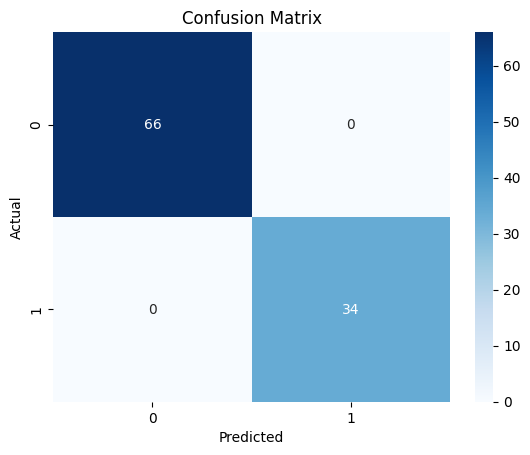

In [276]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**candidate Ranking**

In [277]:
ranked_data = data.sort_values(by="Hiring_Score", ascending=False)

ranked_data["Rank"] = range(1, len(ranked_data) + 1)

ranked_data[["Candidate_ID", "Hiring_Score", "Rank"]].head(10)

,Candidate_ID,Hiring_Score,Rank
117,C118,100.00,1
221,C222,94.26,2
298,C299,94.21,3
358,C359,93.21,4
283,C284,90.83,5
475,C476,90.28,6
421,C422,90.07,7
380,C381,89.14,8
259,C260,89.04,9
91,C92,88.51,10


K_Means Clustering

In [278]:
cluster_features = data[[
    "CGPA",
    "Technical_Skills",
    "Aptitude_Score",
    "Communication_Score",
    "Projects",
    "Internships",
    "Interview_Score",
    "Hiring_Score"
]]

cluster_scaled = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
data["Cluster"] = kmeans.fit_predict(cluster_scaled)

cluster_names = {
    0: "Average",
    1: "Excellent",
    2: "Needs Improvement",
    3: "Strong"
}

data["Candidate_Category"] = data["Cluster"].map(cluster_names)

data[["Candidate_ID", "Hiring_Score", "Candidate_Category"]].head()

,Candidate_ID,Hiring_Score,Candidate_Category
0,C1,69.66,Needs Improvement
1,C2,69.56,Average
2,C3,67.55,Excellent
3,C4,58.06,Average
4,C5,63.81,Strong


**Deep Learning model**

In [279]:
dl_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

dl_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = dl_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6062 - loss: 0.6595 - val_accuracy: 0.7875 - val_loss: 0.5372
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7781 - loss: 0.4942 - val_accuracy: 0.8750 - val_loss: 0.4152
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8875 - loss: 0.3664 - val_accuracy: 0.9000 - val_loss: 0.3258
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9094 - loss: 0.3033 - val_accuracy: 0.9500 - val_loss: 0.2606
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9281 - loss: 0.2561 - val_accuracy: 0.9625 - val_loss: 0.2145
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9344 - loss: 0.2240 - val_accuracy: 0.9500 - val_loss: 0.1853
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9531 - loss: 0.1733 - val_accuracy: 0.9625 - val_loss: 0.1546
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9594 - loss: 0.1472 - val_accuracy: 0.9500 - val_loss: 0.1367
Ep

Deep Learning Evaluation

In [280]:
loss, accuracy = dl_model.evaluate(X_test, y_test)

print("Deep Learning Model Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9600 - loss: 0.1311 
Deep Learning Model Accuracy: 0.9599999785423279


**Data Visualisation**

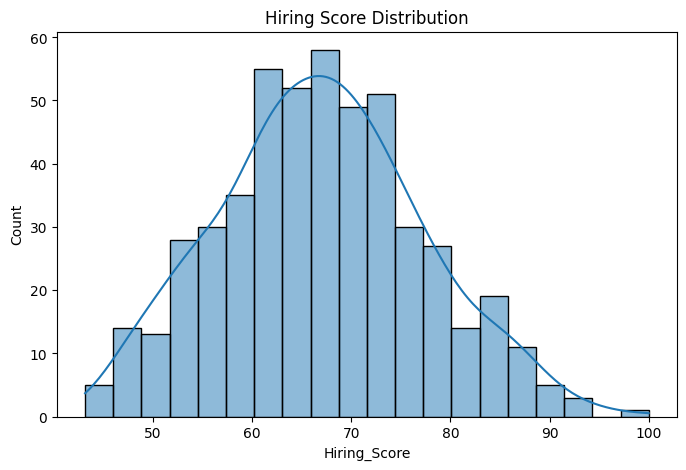

In [281]:
plt.figure(figsize=(8, 5))
sns.histplot(data["Hiring_Score"], bins=20, kde=True)
plt.title("Hiring Score Distribution")
plt.show()

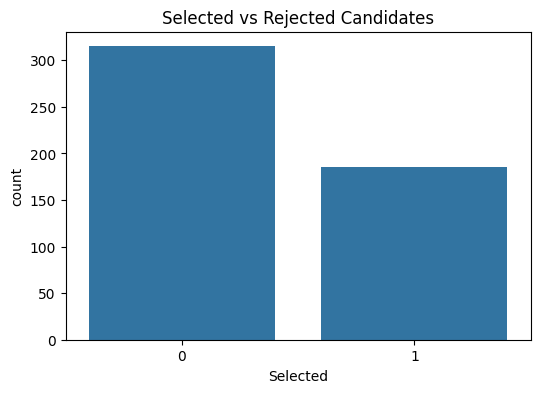

In [282]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Selected", data=data)
plt.title("Selected vs Rejected Candidates")
plt.show()

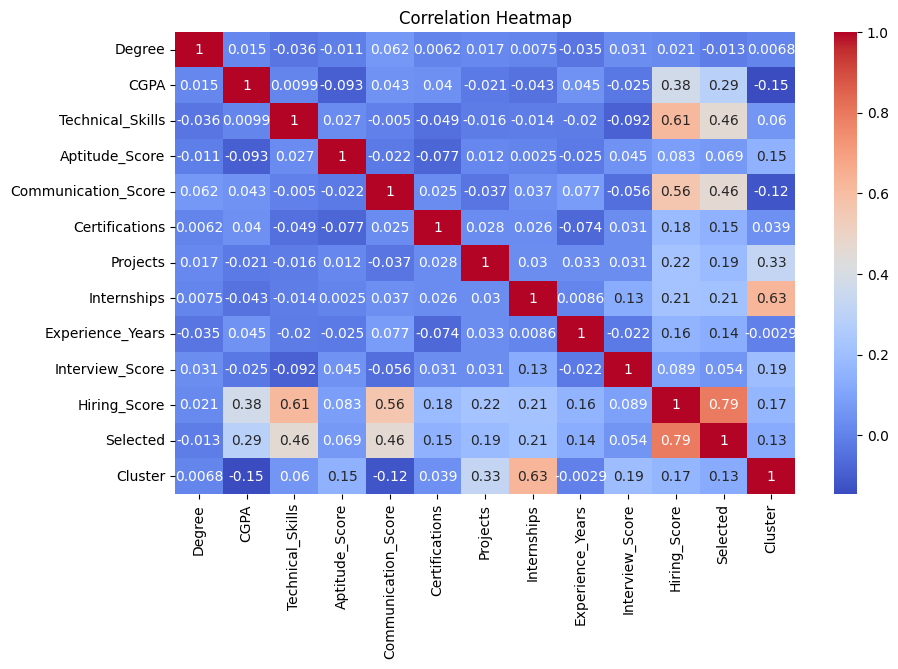

In [283]:
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Predict New Candidate**

In [284]:
new_candidate = pd.DataFrame({
    "Degree": [encoder.transform(["B.Tech"])[0]],
    "CGPA": [8.5],
    "Technical_Skills": [9],
    "Aptitude_Score": [85],
    "Communication_Score": [8],
    "Certifications": [3],
    "Projects": [4],
    "Internships": [2],
    "Experience_Years": [1],
    "Interview_Score": [88],
    "Hiring_Score": [85]
})

new_candidate_scaled = scaler.fit_transform(X)
new_candidate_scaled = scaler.transform(new_candidate)

prediction = rf_model.predict(new_candidate_scaled)

if prediction[0] == 1:
    print("Prediction: Candidate is Selected")
else:
    print("Prediction: Candidate is Rejected")

Prediction: Candidate is Selected


**Final_Output**

In [285]:
final_output = data.sort_values(by="Hiring_Score", ascending=False).copy()

final_output["Rank"] = range(1, len(final_output) + 1)

final_output = final_output[[
    "Candidate_ID",
    "Degree",
    "CGPA",
    "Technical_Skills",
    "Aptitude_Score",
    "Communication_Score",
    "Certifications",
    "Projects",
    "Internships",
    "Experience_Years",
    "Interview_Score",
    "Hiring_Score",
    "Selected",
    "Rank",
    "Candidate_Category"
]]

final_output.to_csv("Smart_Recruitment_Assistant_Output.csv", index=False)

final_output.head()

,Candidate_ID,Degree,CGPA,Technical_Skills,Aptitude_Score,Communication_Score,Certifications,Projects,Internships,Experience_Years,Interview_Score,Hiring_Score,Selected,Rank,Candidate_Category
117,C118,2,9.57,10,65,10,4,5,3,1.4,88,100.00,1,1,Needs Improvement
221,C222,3,9.86,8,92,10,3,4,1,2.2,98,94.26,1,2,Needs Improvement
298,C299,1,7.84,10,69,10,3,4,3,2.6,84,94.21,1,3,Needs Improvement
358,C359,1,7.77,10,62,10,5,5,3,0.8,67,93.21,1,4,Needs Improvement
283,C284,3,8.00,8,61,10,4,5,3,1.2,92,90.83,1,5,Needs Improvement


# 6. **Result:**

The system successfully predicts whether a candidate is selected or rejected. It also generates a Hiring Score, ranks candidates, and categorizes them into different performance groups. The Random Forest model gives better performance for candidate selection prediction.

# 7. **Conclusion:**

The Smart Recruitment Assistant reduces manual screening work and helps recruiters make better hiring decisions. It uses Machine Learning, Deep Learning, and Data Analytics to evaluate candidates objectively and efficiently.